In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast

from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [2]:
import sys
# Ensure this analysis directory is importable regardless of kernel CWD
_here = '/projects/bhdw/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/analysis'
if _here not in sys.path:
    sys.path.insert(0, _here)

import dictys
from utils_custom import *
from pseudotime_curves import *
from episodic_dynamics import *
from config import *

In [3]:
import importlib
import firefate.utils.plots, firefate.utils.custom
import state_dynamics
# re-bind
importlib.reload(firefate.utils.plots)
importlib.reload(firefate.utils.custom)
importlib.reload(state_dynamics)
from state_dynamics import TFForceWaves, StateFrequency
from dynamic_validation import TFForceValidation

In [4]:
config = Config()

In [5]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file('/work/nvme/bhdw/asachan/data_files/firefate/bcell/outs/dynamic.h5')

### Defining lineage trajectories

In [6]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [7]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

## TF forces

In [24]:
# TF forces over pseudotime (expression / regulation curves cached internally)
waves_pb = TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 2),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

In [25]:
# GC branch: same TF-forces machinery over the GC trajectory (node 0 -> 3).
waves_gc = TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 3),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

### FIREFate state-specific enriched links and their forces across both lineages

In [26]:
ss_firefate_combined = pd.read_csv('/projects/bhdw/asachan/tmp/ss_firefate_links_2B.csv')

In [27]:
display(ss_firefate_combined)

,source,target,key,weight,cluster,strength,case
0,PRDM1,RUNX2,1,0.293075,3,1,slide
1,PRDM1,IQGAP2,1,0.219831,3,1,slide
2,BACH2,XBP1,0,-0.229950,7,1,slide
3,BACH2,MZB1,1,-0.234813,3,1,slide
4,BACH2,JCHAIN,1,-0.258168,3,1,slide
...,...,...,...,...,...,...,...
73,PBX3,CDK6,1,0.231756,3,1,slide
74,PBX3,AFF3,1,0.332018,3,1,slide
75,ARID5B,CPEB4,1,0.237878,3,1,slide
76,ARID5B,PDE4D,0,0.228636,7,1,slide


In [28]:
# Build (TF, target) tuples, keeping only links whose TF and target are both
# present in the dictys object. get_beta_curves can only compute forces for genes
# in the GRN (TFs in nids[0], targets in ndict); filtering here makes the computed
# link set explicit rather than relying on the internal skip.
all_links = list(zip(ss_firefate_combined['source'], ss_firefate_combined['target']))

_, _, missing_tfs = get_tf_indices(dictys_dynamic_object, list({tf for tf, _ in all_links}))
missing_tfs = set(missing_tfs)
ndict = dictys_dynamic_object.ndict

ss_firefate_combined_tuple = [(tf, tg) for tf, tg in all_links
                     if tf not in missing_tfs and tg in ndict]
dropped = [(tf, tg) for tf, tg in all_links
           if tf in missing_tfs or tg not in ndict]
print(f"{len(ss_firefate_combined_tuple)}/{len(all_links)} links kept; "
      f"{len(dropped)} dropped (TF/target absent from GRN): {dropped}")

66/78 links kept; 12 dropped (TF/target absent from GRN): [('AFF1', 'MAN1A1'), ('AFF1', 'FNDC3A'), ('AFF1', 'CEP128'), ('HERPUD1', 'TRAM1'), ('HERPUD1', 'IRF4'), ('HERPUD1', 'BTG2'), ('HERPUD1', 'PAX5'), ('HIVEP2', 'IRF4'), ('HIVEP2', 'BTG2'), ('HIVEP2', 'GAB1'), ('HIVEP2', 'GLCCI1'), ('HIVEP2', 'CPEB4')]


In [29]:
# load the episodically enriched links from file
episodic_links_file = '/projects/bhdw/asachan/papers/firefate/figures/enriched_tf_lf_targets_per_episode.csv'
episodic_links = pd.read_csv(episodic_links_file)

In [30]:
display(episodic_links)

,lineage,episode,TF,p_value,genes_in_lf,n_genes_in_lf
0,GC,Ep4,CDC5L,0.003546,"ARNTL2, MZB1, TNFAIP8, UBAC2",4
1,GC,Ep1,CREB3L2,0.009150,"FNDC3A, HSP90B1, LMAN1, SSR1, TRAM1, TXNDC5",6
2,GC,Ep1,IKZF3,0.002195,"ANKRD28, CD74, PIKFYVE, RNF213",4
3,GC,Ep3,IRF7,0.005185,"B2M, CEP128",2
4,GC,Ep4,IRF7,0.001808,"B2M, CEP128",2
5,GC,Ep4,MEF2C,0.000220,"IRF4, SEL1L3, SLA, TNFAIP8",4
6,GC,Ep4,POU2F1,0.006940,"CCSER2, DEK, EEA1, IRF4, MAPK1, SLC25A13",6
7,GC,Ep3,USF2,0.001520,"FNDC3A, HSP90B1, LMAN1, RNF213, SSR1, SUB1, TRAM1",7
8,GC,Ep4,USF2,0.004210,"FNDC3A, HSP90B1, LMAN1, RNF213, SSR1, SUB1, TRAM1",7
9,PB,Ep1,CREB3L2,0.000220,"FNDC3A, HSP90B1, LMAN1, SSR1, TRAM1",5


In [31]:
#create tuples from the TF and genes_in_lf list of comma separated targets and take union of all links across all rows to make a unique set of links
episodic_links_tuples = set()
for _, row in episodic_links.iterrows():
    tf = row['TF']
    targets = row['genes_in_lf'].split(',')
    for target in targets:
        episodic_links_tuples.add((tf, target.strip()))


In [32]:
display(len(episodic_links_tuples))

55

## Cross-branch pooled comparison (PB ∪ GC)

,link,group,branch,abs_max_force
0,"(IRF7, CEP128)",enriched,GC,0.572163
1,"(MEF2C, TNFAIP8)",enriched,GC,0.668315
2,"(IRF8, CEP128)",enriched,PB,0.679680
3,"(MEF2A, SLA)",enriched,PB,1.038609
4,"(USF2, SSR1)",enriched,GC,0.831089
...,...,...,...,...
105,"(ZNF177, PLEKHA1)",random,PB,0.005573
106,"(ZNF134, AGPAT5)",random,GC,0.128612
107,"(MBNL2, BRCA1)",random,GC,0.263512
108,"(TCF7L2, PLEKHA1)",random,GC,0.151656


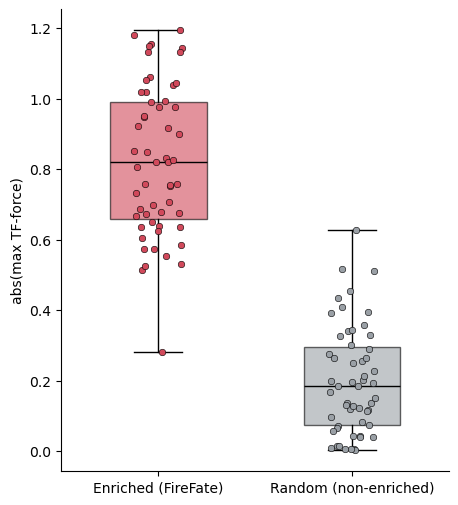

In [16]:
# The 66 enriched links act on both the PB and GC branches, so collapsing a single
# branch across phases under-separates them. Score each enriched link on BOTH branches
# and keep its abs-max TF force across branches; the random null is the UNION of the
# per-branch random pools (each random link keeps its own single-branch force, not a
# cross-branch max), size-matched to the enriched links. The result keeps a
# 'branch' column = the lineage where each enriched link's force was strongest.

xval_episodic = TFForceValidation(
    {'PB': waves_pb, 'GC': waves_gc},
    enriched_links=episodic_links_tuples,
    varname='w_in',
    mode='combined',
)
xval_df_ep = xval_episodic.run(exclude='tf_and_target', random_state=0)
display(xval_df_ep)

fig, ax = xval_episodic.plot(ylabel='abs(max TF-force)')
#save as svg with editable text
fig.savefig('/projects/bhdw/asachan/papers/firefate/figures/episodic_links_validation.svg', format='svg', bbox_inches='tight')
plt.show()

group
State-specific    66
random            66
Episodic          55
Name: count, dtype: int64

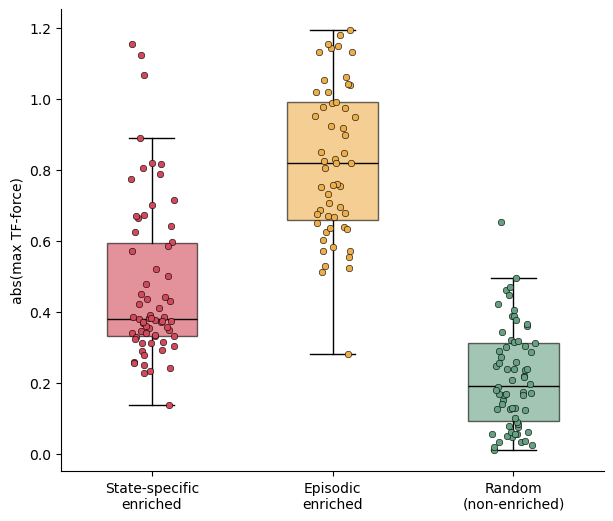

In [17]:
# Combined 3-box comparison: state-specific enriched, episodic enriched, and ONE shared
# random null (size-matched to the larger of the two enriched sets; drawn with every
# TF/target from BOTH sets removed). Each link scored by abs-max TF force across PB & GC.
combo_df = TFForceValidation.compare_sets(
    {'PB': waves_pb, 'GC': waves_gc},
    {'State-specific': ss_firefate_combined_tuple,
     'Episodic': episodic_links_tuples},
    varname='w_in', exclude='tf_and_target', random_state=0,
)
display(combo_df['group'].value_counts())

fig, ax = TFForceValidation.plot_multi(
    combo_df,
    group_order=['State-specific', 'Episodic', 'random'],
    group_labels=['State-specific\nenriched', 'Episodic\nenriched', 'Random\n(non-enriched)'],
    ylabel='abs(max TF-force)',
)
fig.savefig('/projects/bhdw/asachan/papers/firefate/figures/combined_links_validation.svg',
            format='svg', bbox_inches='tight')
plt.show()

# Phase split validation

In [33]:
# Class 1: cell-state fate frequencies + extrema / termination pseudotimes
sf_pb = StateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 2),
)
pseudotime_values_of_windows_pb = sf_pb.pseudotime_values_of_windows

In [34]:
# Class 1: cell-state fate frequencies + extrema / termination pseudotimes
sf_gc = StateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 3),
)
pseudotime_values_of_windows_gc = sf_gc.pseudotime_values_of_windows

In [ ]:
# PB switch boundaries = termination pseudotimes of ActB-4 then earlyPB (3 phases).
pb_switches = [sf_pb.termination_pseudotime(s, PB_post_bifurcation_window_indices,
                                            method='threshold')
               for s in ['ActB-4', 'earlyPB']]

# GC switch boundary = termination pseudotime of ActB-3 (2 phases).
gc_switches = [sf_gc.termination_pseudotime('ActB-3', GC_post_bifurcation_window_indices,
                                            method='threshold')]

In [35]:
import importlib, dynamic_validation
importlib.reload(dynamic_validation)
from dynamic_validation import TFForceValidation

# PB switch boundaries = termination pseudotimes of ActB-4 then earlyPB (3 phases).
pb_switches = [sf_pb.termination_pseudotime(s, PB_post_bifurcation_window_indices,
                                            method='threshold')
               for s in ['ActB-4', 'earlyPB']]

# Classify the universe of enriched links (state-specific + episodic) into PB phases,
# keeping only links whose winning branch is PB, then compare the two enriched sets
# against ONE shared per-phase random null. Each point is a link's abs-max TF force,
# which (since phase = where the force peaks) is its in-phase peak force.
pb_phase_df = TFForceValidation.compare_sets_by_phase(
    {'PB': waves_pb, 'GC': waves_gc},
    {'State-specific': ss_firefate_combined_tuple,
     'Episodic': episodic_links_tuples},
    switch_pseudotimes={'PB': pb_switches},
    varname='w_in', exclude='tf_and_target', random_state=0,
)
display(pb_phase_df.groupby(['phase', 'group']).size().unstack(fill_value=0))

group,Episodic,State-specific,random
phase,,,
1,3,10,10
2,19,23,23
3,8,18,18


In [36]:
# GC switch boundary = termination pseudotime of ActB-3 (2 phases).
gc_switches = [sf_gc.termination_pseudotime('ActB-3', GC_post_bifurcation_window_indices,
                                            method='threshold')]

# Classify the universe of enriched links (state-specific + episodic) into GC phases,
# keeping only links whose winning branch is GC, then compare the two enriched sets
# against ONE shared per-phase random null. Each point is a link's abs-max TF force,
# which (since phase = where the force peaks) is its in-phase peak force.
gc_phase_df = TFForceValidation.compare_sets_by_phase(
    {'PB': waves_pb, 'GC': waves_gc},
    {'State-specific': ss_firefate_combined_tuple,
     'Episodic': episodic_links_tuples},
    switch_pseudotimes={'GC': gc_switches},
    varname='w_in', exclude='tf_and_target', random_state=0,
)
display(gc_phase_df.groupby(['phase', 'group']).size().unstack(fill_value=0))

group,Episodic,State-specific,random
phase,,,
1,17,13,17
2,8,2,8


In [ ]:
fig, ax = TFForceValidation.plot_multi_by_phase(
    pb_phase_df, branch='PB',
    group_order=['State-specific', 'Episodic', 'random'],
    group_labels=['State-specific', 'Episodic', 'Random (non-enriched)'],
    ylabel='Abs max TF force (in-phase)',
    xlabel= ['Phase 1', 'Phase 2', 'Phase 3']
)
ax.set_title('PB phases')
fig.savefig('/projects/bhdw/asachan/papers/firefate/figures/pb_phase_links_validation.svg',
            format='svg', bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = TFForceValidation.plot_multi_by_phase(
    gc_phase_df, branch='GC',
    group_order=['State-specific', 'Episodic', 'random'],
    group_labels=['State-specific', 'Episodic', 'Random (non-enriched)'],
    ylabel='Abs max TF force (in-phase)',
    xlabel=['Phase 1', 'Phase 2'],
)
ax.set_title('GC phases')
fig.savefig('/projects/bhdw/asachan/papers/firefate/figures/gc_phase_links_validation.svg',
            format='svg', bbox_inches='tight')
plt.show()

# TF Binding Dynamics

In [8]:
# list static and episodic TFs
static_tfs_fig3 = [
    'CREB3L2',
    'PRDM1',
    'IRF4',
    'BATF',
    'PAX5',
]
episodic_tfs_fig3 = [
    'MEF2C',
    'USF2',
    'IRF7',
    'TFEC',
    'TEAD2',
]
pb_lineage_tfs_fig3 = [
    'RUNX2',
    'CREB3L2',
    'PRDM1',
    'IRF4',
    'XBP1',
]
gc_lineage_tfs_fig3 = [
    'BACH2',
    'SPIB',
    'BATF',
    'PAX5',
    'IRF8',
]

static_tfs_fig4 = ['PAX5',
    'BATF',
    'BACH2']
episodic_tfs_fig4 = ['IKZF2',
    'RBPJ',
    'NFATC2']
other_tfs_fig4 = ['NR4A3',
    'MXI1',
    'TRPS1']

all_tfs_fig3 = list(set(static_tfs_fig3 + episodic_tfs_fig3 + pb_lineage_tfs_fig3 + gc_lineage_tfs_fig3))
all_tfs_fig4 = list(set(static_tfs_fig4 + episodic_tfs_fig4 + other_tfs_fig4))
base_path = '/work/nvme/bhdw/asachan/data_files/firefate/bcell/tmp_dynamic'

In [16]:
categories_fig3 = {
    "Static": {
        "CREB3L2": "#3F007D",  # Purple-5 (darkest)
        "PRDM1":   "#6A51A3",  # Purple-4
        "IRF4":    "#9E9AC8",  # Purple-3
        "BATF":    "#CBC9E2",  # Purple-2
        "PAX5":    "#F2F0F7",  # Purple-1 (lightest)
    },
    "Episodic": {
        "MEF2C":  "#7F2704",   # Orange-5 (darkest)
        "USF2":   "#D94801",   # Orange-4
        "IRF7":   "#F16913",   # Orange-3
        "TFEC":   "#FD8D3C",   # Orange-2
        "TEAD2":  "#FEE6CE",   # Orange-1 (lightest)
    },
    "PB Lineage": {
        "RUNX2":   "#67000D",  # Red-5 (darkest)
        "CREB3L2": "#A50F15",  # Red-4
        "PRDM1":   "#EF3B2C",  # Red-3
        "IRF4":    "#FC9272",  # Red-2
        "XBP1":    "#FEE0D2",  # Red-1 (lightest)
    },
    "GC Lineage": {
        "BACH2":   "#00441B",  # Green-5 (darkest)
        "SPIB":    "#238B45",  # Green-4
        "BATF":    "#41AB5D",  # Green-3
        "PAX5":    "#A1D99B",  # Green-2
        "IRF8":    "#E5F5E0",  # Green-1 (lightest)
    },
}

categories_fig4 = {
    "Static": {
        "PAX5":    "#DADAEB",  # Lighter purple
        "BATF":    "#BCBDDC",  # Light purple
        "BACH2":   "#9E9AC8",  # Medium purple
    },
    "Episodic": {
        "IKZF2":   "#D94701",   # Dark orange
        "RBPJ":    "#F16913",   # Orange
        "NFATC2":  "#FD8D3C",   # Medium orange
    },
    "Other": {
        "NR4A3": "#08519C",  # Dark blue
        "MXI1": "#3182BD",  # Medium blue
        "TRPS1": "#9ECAE1"  # Light blue
    }
}


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from itertools import cycle


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def softmax_binned_series(binned_series, tfs, temperature=0.01):
    """
    Apply per-bin softmax to a binned TF series.

    Parameters
    ----------
    binned_series : {tf: [bin0_vals, bin1_vals, ...]}
    tfs           : list of TF names to apply softmax to
    temperature   : float, controls sharpness (lower = more peaked)
    """
    return {
        tf: [
            np.exp(vals / temperature) / np.sum(np.exp(vals / temperature))
            for vals in binned_series[tf]
        ]
        for tf in tfs
    }


def _get_series(chromatin_object, lineage, metric):
    """
    Extract the correct series dict and pseudotime array from a chromatin object.

    Parameters
    ----------
    lineage : 'pb' | 'gc'
    metric  : 'score' | 'count'
    """
    if lineage == 'pb':
        pseudotime = chromatin_object.pb_pseudotime
        series = chromatin_object.series_pb
    elif lineage == 'gc':
        pseudotime = chromatin_object.gc_pseudotime
        series = chromatin_object.series_gc
    else:
        raise ValueError(f"lineage must be 'pb' or 'gc', got '{lineage}'")
    return pseudotime, series


In [22]:
# ---------------------------------------------------------------------------
# Core binning
# ---------------------------------------------------------------------------

def make_bins(
    chromatin_object,
    switch_pseudotimes,         # phase boundaries = cell-state termination pseudotimes,
                                # e.g. pb_switches / gc_switches (N switches -> N+1 phases)
    lineage,                    # 'pb' | 'gc'
    metric='score',             # 'score' | 'count' — for y-axis labelling only
    tfs=None,                   # subset of TFs to bin; None = all TFs in object
    softmax=False,
    softmax_temperature=0.01,
):
    """
    Bin a chromatin object's TF series into temporal *phases* along one lineage.

    Each window is assigned to a phase by its pseudotime, using the SAME rule as
    RegulatoryPhases.assign_phases: np.digitize(pseudotime, boundaries, right=True).
    `switch_pseudotimes` are the cell-state termination pseudotimes separating
    consecutive phases (N switches -> N+1 phases), so a chromatin window lands in
    the same phase as a link whose force peaks at that pseudotime.

    Parameters
    ----------
    chromatin_object    : SmoothedCurvesChromatin / CountChromatin (has
                          pb_pseudotime/gc_pseudotime and series_pb/series_gc)
    switch_pseudotimes  : sequence of phase-boundary pseudotimes (e.g. pb_switches)
    lineage             : 'pb' | 'gc'
    metric              : 'score' | 'count', stored in result for downstream use
    tfs                 : list[str] | None, TFs to include (default: all in object)
    softmax             : bool
    softmax_temperature : float

    Returns
    -------
    dict:
        binned_series : {tf: [phase1_vals, phase2_vals, ...]}
        bin_labels    : np.array of phase index (0-based) per window
        pseudotime    : pseudotime values per window (this lineage)
        series        : {tf: values} (this lineage, the TFs binned)
        n_bins        : int, number of phases (= len(switch_pseudotimes) + 1)
        lineage       : 'pb' | 'gc'
        metric        : 'score' | 'count'
    """
    # phase boundaries -> N+1 phases (same binning rule as RegulatoryPhases.assign_phases)
    boundaries = np.sort(np.asarray(switch_pseudotimes, dtype=float))
    n_bins = len(boundaries) + 1

    # extract pseudotime + series for this lineage
    pseudotime, series = _get_series(chromatin_object, lineage, metric)

    if not series:
        raise ValueError(
            f"chromatin_object.series_{lineage} is empty — run extract_data() and "
            "process_dynamics() before make_bins()."
        )

    # optionally restrict to a TF subset
    if tfs is not None:
        series = {tf: series[tf] for tf in tfs if tf in series}

    # bin every window to a phase by its pseudotime (phase = bin_labels + 1)
    bin_labels = np.digitize(pseudotime, boundaries, right=True)

    # bin TF series
    binned_series = {
        tf: [vals[bin_labels == b] for b in range(n_bins)]
        for tf, vals in series.items()
    }

    # optional softmax
    if softmax:
        binned_series = softmax_binned_series(binned_series, list(binned_series.keys()), softmax_temperature)

    # sanity check
    tf_ex = next(iter(binned_series))
    print(f"[{lineage.upper()} | {metric}] Phase sizes for '{tf_ex}':")
    for b, arr in enumerate(binned_series[tf_ex]):
        print(f"  Phase {b + 1}: {len(arr)} windows")

    return dict(
        binned_series=binned_series,
        bin_labels=bin_labels,
        pseudotime=pseudotime,
        series=series,
        n_bins=n_bins,
        lineage=lineage,
        metric=metric,
    )

In [20]:
def plot_single_lineage_tf_category_bins(
    result,
    tf_categories,
    title,
    show_other=True,
    fill_opacity=0.5,
    skip_when_not_other=('PB Lineage', 'GC Lineage'),
):
    """
    Plotly boxplot of mean TF values per bin, grouped by category.
    Each dot = one TF's mean value in that bin.

    Parameters
    ----------
    result               : dict returned by make_bins (single lineage)
    tf_categories        : dict {category_name: {tf: hex_color} | list[str]}
    title                : str
    show_other           : if False, skip categories listed in
                           `skip_when_not_other`. All other categories
                           (Static, Episodic, Random, ...) are shown.
    skip_when_not_other  : tuple of category names to drop when show_other=False.
                           Defaults to the lineage categories from fig3.
    """
    binned_series = result['binned_series']
    n_bins        = result['n_bins']
    metric        = result['metric']
    y_label       = {'score': 'Mean TF Binding Score', 'count': 'Mean TF Count'}.get(metric, metric)

    fallback_palette = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261', '#9b2335']
    bin_labels = [f'Bin {b}' for b in range(n_bins)]
    fig = go.Figure()

    def hex_to_rgba(hex_color, alpha):
        h = hex_color.lstrip('#')
        r, g, b = tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
        return f'rgba({r},{g},{b},{alpha})'

    for (cat, tfs_entry), fallback_color in zip(tf_categories.items(), cycle(fallback_palette)):
        # NEW: explicit skip-list rather than implicit allow-list
        if not show_other and cat in skip_when_not_other:
            continue

        if isinstance(tfs_entry, dict):
            tfs       = list(tfs_entry.keys())
            cat_color = next(iter(tfs_entry.values()))
        else:
            tfs       = tfs_entry
            cat_color = fallback_color

        fill_rgba = hex_to_rgba(cat_color, fill_opacity)

        # mean per TF per bin → (n_tfs, n_bins)
        means = np.array([
            [np.mean(binned_series[tf][b]) if tf in binned_series and len(binned_series[tf][b]) > 0 else np.nan
             for b in range(n_bins)]
            for tf in tfs
        ])

        for b in range(n_bins):
            fig.add_trace(go.Box(
                x=[bin_labels[b]] * len(tfs),
                y=means[:, b],
                name=cat,
                legendgroup=cat,
                showlegend=(b == 0),
                marker=dict(color=cat_color, size=10, opacity=0.9),
                line=dict(color=cat_color),
                fillcolor=fill_rgba,
                boxpoints='all',
                pointpos=0,
                jitter=0.3,
                text=tfs,
                hovertemplate='<b>%{text}</b><br>Mean: %{y:.4f}<extra></extra>',
            ))

    fig.update_layout(
        title=title,
        xaxis_title='Bin',
        yaxis_title=y_label,
        boxmode='group',
        template='plotly_white',
        legend=dict(groupclick='toggleitem'),
        height=500,
        width=900,
    )
    return fig

In [9]:
smooth_chromatin_object = SmoothedCurvesChromatin(
    tfs=None,
    base_path=base_path
)

In [10]:
# Get pseudotime values for all windows
aligner_pb = AlignTimeScales(
    dictys_dynamic_object=dictys_dynamic_object,
    trajectory_range=(1, 2),  # any trajectory starting from 1
    num_points=40,
    dist=0.001,
    sparsity=0.01
)
aligner_gc = AlignTimeScales(
    dictys_dynamic_object=dictys_dynamic_object,
    trajectory_range=(1, 3),  # any trajectory starting from 1
    num_points=40,
    dist=0.001,
    sparsity=0.01
)
window_pseudotimes = aligner_pb.pseudotime_of_windows()

In [11]:
smooth_chromatin_object.set_trajectory_info(
    pb_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2],
    gc_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3],
    window_pseudotimes=window_pseudotimes
)

In [13]:
smooth_chromatin_object.extract_data(n_windows=194, n_processes=None)

Processing 194 windows using 127 processes...


Extracting Binding Data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 194/194 [00:01<00:00, 146.20it/s]


Discovered 0 TFs across all windows.
Extraction complete.


In [14]:
smooth_chromatin_object.process_dynamics(metric='score', smooth_sigma=2.0, relative=False)

In [23]:
# --- bin score (smooth chromatin) by phase ---
result_pb = make_bins(
    chromatin_object=smooth_chromatin_object,
    switch_pseudotimes=pb_switches,   # [ActB-4_term, earlyPB_term] -> 3 phases
    lineage='pb',
    metric='score',
    tfs=None,
    softmax=False,
    softmax_temperature=0.01,
)
result_gc = make_bins(
    chromatin_object=smooth_chromatin_object,
    switch_pseudotimes=gc_switches,   # [ActB-3_term] -> 2 phases
    lineage='gc',
    metric='score',
    tfs=None,
    softmax=False,
    softmax_temperature=0.01,
)

NameError: name 'pb_switches' is not defined